# Hidden Markov Models for NLP

A guided tour of **Hidden Markov Models** with a focus on natural-language applications, drawing on:

- Mark Stamp, *A Revealing Introduction to Hidden Markov Models* (2021).
- Daniel Jurafsky & James H. Martin, *Speech and Language Processing*, Ch. 8 & Appendix A (2023).

The running example throughout is **part-of-speech (POS) tagging** — the historical "hello world" of HMMs in NLP — but the same machinery underpins:

- **Speech recognition** — phonemes (hidden) generate acoustic frames (observed).
- **Named-entity recognition (NER)** — entity-type tags generate words.
- **Word/sentence segmentation** — boundary states generate characters.
- **Language and dialect identification** — language states generate text.
- **Spelling correction & transliteration** — intended characters generate observed ones.

The notebook is **self-contained** and runs in Google Colab without manual setup.

---

## 📚 Table of contents

1. **Why HMMs in NLP?** — motivation through POS tagging.
2. **Markov chains as bigram language models.**
3. **The Hidden Markov Model** — words as observations, tags as hidden states.
4. **The three fundamental problems** of HMMs, in NLP terms.
5. **Problem 1 — Likelihood:** the *Forward algorithm* (and *Backward*).
6. **Problem 2 — Decoding:** *Viterbi* — *this is the POS tagger*.
7. **Problem 3a — Supervised learning:** maximum-likelihood estimation from a tagged corpus.
8. **A real experiment:** training & evaluating an HMM POS tagger on the Brown corpus.
9. **Problem 3b — Unsupervised learning:** the *Baum–Welch* (Forward–Backward) algorithm.
10. **Unsupervised structure discovery:** rediscovering vowels vs. consonants from raw text.
11. **Summary, limitations & where to go next.**


## 1. Why HMMs in NLP?

Most NLP problems have an obvious sequence structure: words come in order, characters come in order, phonemes come in order. Many also have a **hidden** layer of structure that we'd like to recover:

| Application | What we observe | What's hidden |
|---|---|---|
| POS tagging | the words of a sentence | the part-of-speech of each word |
| NER | the words | whether each word is part of a person/place/org |
| Speech recognition | acoustic feature frames | the phonemes / words |
| Chunking | the words and tags | shallow phrase boundaries |
| Word segmentation (Chinese) | the characters | word boundaries |
| OCR post-correction | the recognized characters | the intended characters |

POS tagging is the canonical example, and we'll build the whole notebook around it.

**The POS-tagging task.** Given a sentence
$$
\mathbf{w} = (w_1, w_2, \dots, w_T),
$$
assign each word a part-of-speech tag $t_i$ from a fixed tagset (e.g. NOUN, VERB, DET, ADJ, …). The output is a tag sequence
$$
\mathbf{t} = (t_1, t_2, \dots, t_T)
$$
of the same length. For example:

```
The   dog   barks   loudly
DET   NOUN  VERB    ADV
```

Why is this hard? Because words are **ambiguous**: *book* can be a noun ("the book") or a verb ("book a ticket"); *runs* can be a verb or a noun. The right tag depends on **context**.

HMMs solve this by modelling two interacting probability distributions:

1. How likely is each tag given the previous tag? (a **Markov chain over tags**)
2. How likely is each word given its tag? (an **emission distribution**)

We then ask: *which tag sequence $\mathbf{t}^*$ best explains the observed words $\mathbf{w}$?* That's the **Viterbi algorithm**, and it's the centrepiece of this notebook.


### Setup

Run this cell first.

In [ ]:
# ---- Install / import the libraries we need ----
# nltk is pre-installed in Colab but its corpora are not — we download them below.
!pip install hmmlearn --quiet

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import nltk
from collections import Counter, defaultdict

# Reproducibility
np.random.seed(42)

# Pretty-print numpy arrays
np.set_printoptions(precision=4, suppress=True)

# Download the Brown corpus (used in section 8) and the universal-tagset mapping.
# These downloads are tiny (~3 MB) and only happen once per Colab session.
nltk.download('brown',                quiet=True)
nltk.download('universal_tagset',     quiet=True)
nltk.download('punkt',                quiet=True)

print("Setup complete ✔")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.2 MB/s eta 0:00:00
Setup complete ✔


## 2. Markov chains as bigram language models

Before we hide anything, let's understand the *visible* version: a **Markov chain**.

A Markov chain is a model of a sequence of random variables $q_1, q_2, q_3, \dots$ that satisfies the **Markov assumption**:

$$
\boxed{\;P(q_i \mid q_1, q_2, \dots, q_{i-1}) \;=\; P(q_i \mid q_{i-1})\;}
$$

In words: **to predict the next state, only the current state matters** — the further past is irrelevant *given* the present.

A Markov chain is fully described by three pieces:

- **States.** A finite set $Q = \{q_0, q_1, \dots, q_{N-1}\}$ of $N$ possible values.
- **Transition matrix.** A row-stochastic matrix $A \in \mathbb{R}^{N\times N}$ whose entries
$$
a_{ij} \;=\; P\!\bigl(q_j \text{ at time } t{+}1 \,\big|\, q_i \text{ at time } t\bigr)
$$
give the probability of jumping from state $i$ to state $j$ in one step. Each row of $A$ sums to $1$.
- **Initial distribution.** A vector $\pi \in \mathbb{R}^{N}$ with $\pi_i = P(q_0 = i)$, the probability of starting in state $i$. Its entries sum to $1$.

A matrix in which every row is a probability distribution (non-negative and summing to 1) is called **row-stochastic**.

### NLP connection: Markov chains *are* bigram language models

If the states are **words**, then a Markov chain over those states is exactly a **bigram language model**: the probability of the next word depends only on the previous word. Computing
$$
P(w_1, w_2, \dots, w_T) \;\approx\; P(w_1)\,\prod_{i=2}^{T} P(w_i \mid w_{i-1})
$$
is precisely a Markov-chain probability. So a Markov chain is something every NLP student has already met under another name.

Below we estimate a bigram model from a tiny toy corpus and use it to *generate* text by random sampling — the simplest possible "language model" in action.


In [ ]:
# A tiny toy corpus of 4 sentences. <s> = sentence-start, </s> = sentence-end.
# We use these special tokens so the model can learn what words start/end sentences.
toy_corpus = [
    "<s> the dog barks loudly </s>",
    "<s> the cat sleeps quietly </s>",
    "<s> the dog sleeps </s>",
    "<s> a cat barks loudly </s>",
]

# Tokenise into a list of (word_i, word_{i+1}) bigrams across all sentences.
bigrams = []
unigrams = []
for sent in toy_corpus:
    tokens = sent.split()
    unigrams.extend(tokens)
    bigrams.extend(zip(tokens[:-1], tokens[1:]))

# Count bigrams and the total occurrences of each "left" word — these are the
# numerator and denominator of the MLE bigram probability:
#         P(w_i | w_{i-1}) = C(w_{i-1}, w_i) / C(w_{i-1})
bigram_counts  = Counter(bigrams)
left_counts    = Counter(w1 for (w1, _) in bigrams)

# Print a few bigram probabilities
print("MLE bigram probabilities:")
for (w1, w2), c in sorted(bigram_counts.items()):
    p = c / left_counts[w1]
    print(f"  P({w2:>8s} | {w1:<3s}) = {c}/{left_counts[w1]} = {p:.3f}")


MLE bigram probabilities:
  P(       a | <s>) = 1/4 = 0.250
  P(     the | <s>) = 3/4 = 0.750
  P(     cat | a  ) = 1/1 = 1.000
  P(  loudly | barks) = 2/2 = 1.000
  P(   barks | cat) = 1/2 = 0.500
  P(  sleeps | cat) = 1/2 = 0.500
  P(   barks | dog) = 1/2 = 0.500
  P(  sleeps | dog) = 1/2 = 0.500
  P(    </s> | loudly) = 2/2 = 1.000
  P(    </s> | quietly) = 1/1 = 1.000
  P(    </s> | sleeps) = 1/2 = 0.500
  P( quietly | sleeps) = 1/2 = 0.500
  P(     cat | the) = 1/3 = 0.333
  P(     dog | the) = 2/3 = 0.667


In [ ]:
# Build a transition-probability dict-of-dicts so we can easily sample the next word.
def build_bigram_lm(bigram_counts, left_counts):
    '''Return {prev_word: {next_word: P(next | prev)}}.'''
    lm = defaultdict(dict)
    for (w1, w2), c in bigram_counts.items():
        lm[w1][w2] = c / left_counts[w1]
    return lm

bigram_lm = build_bigram_lm(bigram_counts, left_counts)

# Generate a few sentences by walking the chain from <s> until we hit </s>.
def sample_sentence(lm, rng, start='<s>', stop='</s>', max_len=15):
    out, w = [start], start
    for _ in range(max_len):
        if w not in lm:
            break
        next_words = list(lm[w].keys())
        probs      = list(lm[w].values())
        w = rng.choice(next_words, p=probs)
        out.append(w)
        if w == stop:
            break
    return out

rng = np.random.default_rng(0)
print("\nSampled sentences from the bigram LM:")
for _ in range(5):
    print("  ", " ".join(sample_sentence(bigram_lm, rng)))



Sampled sentences from the bigram LM:
   <s> the dog barks loudly </s>
   <s> a cat barks loudly </s>
   <s> a cat barks loudly </s>
   <s> the cat barks loudly </s>
   <s> the dog sleeps </s>


These sentences are silly, but they're **structurally valid** for the corpus we trained on. That's exactly what a good language model should do: assign high probability to plausible word sequences and low probability to nonsense ones. We'll come back to this idea in section 5 when we use the Forward algorithm to score sentences under an HMM.

### Visualising the chain

Drawing the states as nodes and the transitions as labelled arrows makes the structure tangible.


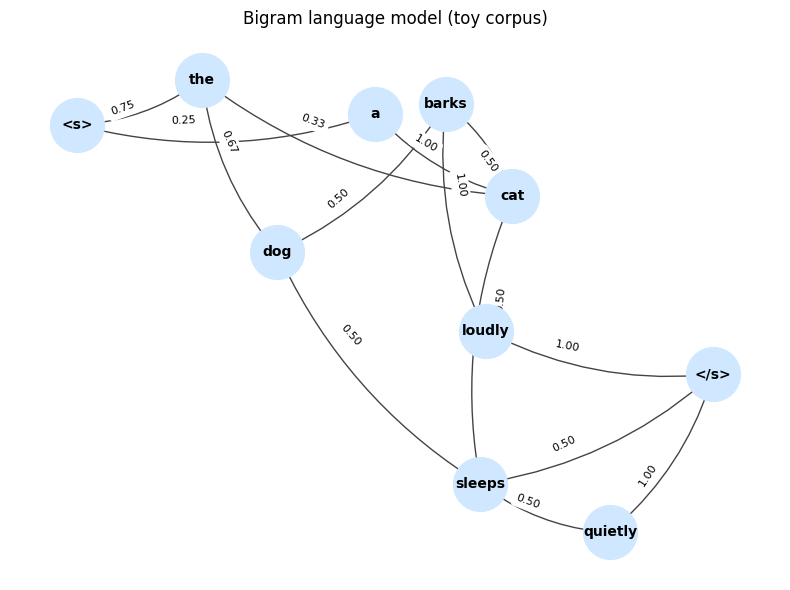

In [ ]:
def draw_markov_chain(transitions, title, layout="circular", node_color="#cfe7ff"):
    '''Draw a Markov chain whose transitions are given as {from: {to: prob}}.'''
    G = nx.MultiDiGraph()
    for src, dests in transitions.items():
        for dst, p in dests.items():
            if p > 0:
                G.add_edge(src, dst, weight=p)

    if layout == "circular":
        pos = nx.circular_layout(G)
    else:
        pos = nx.spring_layout(G, seed=1)

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=node_color, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(
        G, pos, connectionstyle="arc3,rad=0.15",
        arrowsize=15, edge_color="#444", ax=ax,
    )
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, label_pos=0.35, font_size=8, ax=ax
    )
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_markov_chain(bigram_lm, "Bigram language model (toy corpus)", layout="spring")


## 3. The Hidden Markov Model — POS tagging in pictures

A plain Markov chain over **words** is fine, but it doesn't help us with tasks where we need to recover *latent structure*. For POS tagging we need a model where the **tags** form the Markov chain and the **words** are stochastic emissions of those tags.

That's an HMM.

An HMM is a Markov chain over hidden states $q_t$, plus an extra observation $o_t$ at each time step that depends only on the current state. It is described by:

- $Q = \{q_0, \dots, q_{N-1}\}$ — the $N$ hidden states (tags, in our case).
- $V = \{0, 1, \dots, M-1\}$ — the $M$ observation symbols (words, in our case).
- $A \in \mathbb{R}^{N\times N}$ — transition matrix between hidden states, $a_{ij} = P(q_j \text{ at } t{+}1 \mid q_i \text{ at } t)$.
- $B \in \mathbb{R}^{N\times M}$ — emission matrix, $b_j(k) = P(\text{observation } k \mid \text{state } q_j)$.
- $\pi \in \mathbb{R}^{N}$ — initial state distribution.

We write $\lambda = (A, B, \pi)$ for the whole model.

The two **assumptions** are:

1. **Markov assumption (states):** $\;P(q_t \mid q_1,\dots,q_{t-1}) = P(q_t \mid q_{t-1})$.
2. **Output independence (emissions):** $\;P(o_t \mid q_1,\dots,q_T,\, o_1,\dots,o_T) = P(o_t \mid q_t)$.

For POS tagging that means:

- The next tag depends only on the current tag (a **bigram tag model**).
- The current word depends only on the current tag — *not* on the surrounding words or other tags.

Both are obvious oversimplifications — but they make the algorithms tractable and the model surprisingly competitive (HMM POS taggers reached ~96% accuracy on English long before neural methods existed).

### A toy POS-tagging HMM

Let's build a small concrete HMM with 3 tags and 6 words. Don't worry about how the numbers were chosen yet — in section 7 we'll learn them from data.


In [ ]:
# ---------------------------------------------------------------
# Toy POS-tagging HMM
# ---------------------------------------------------------------
# Hidden states (tags). Index order matters: state 0 = DET, 1 = NOUN, 2 = VERB.
tags = ["DET", "NOUN", "VERB"]

# Observation alphabet (vocabulary). 6 words for the toy example.
vocab = ["the", "a", "dog", "cat", "barks", "sleeps"]

# Map words/tags to integer indices for use in numpy.
tag2idx  = {t: i for i, t in enumerate(tags)}
word2idx = {w: i for i, w in enumerate(vocab)}

# Initial-state distribution pi.
# We assume sentences usually start with DET ("the dog ..."), occasionally a NOUN.
pi = np.array([0.8, 0.2, 0.0])

# Transition matrix A. Rows indexed by current tag, columns by next tag.
# Linguistic intuition baked in:
#   - DET tends to be followed by NOUN.
#   - NOUN tends to be followed by VERB (subject-verb).
#   - VERB can transition anywhere (sentence may end too — we ignore </s> here).
A = np.array([
    # to:  DET    NOUN   VERB
    [      0.0,   0.9,   0.1],   # from DET
    [      0.1,   0.2,   0.7],   # from NOUN
    [      0.4,   0.4,   0.2],   # from VERB
])

# Emission matrix B. Rows = tag, columns = word.
# DET emits articles ("the", "a"); NOUN emits nouns; VERB emits verbs.
B = np.array([
    # the    a    dog   cat  barks sleeps
    [0.6,   0.4,  0.0,  0.0,  0.0,  0.0],   # DET
    [0.0,   0.0,  0.5,  0.5,  0.0,  0.0],   # NOUN
    [0.0,   0.0,  0.0,  0.0,  0.6,  0.4],   # VERB
])

# Sanity checks.
assert np.allclose(A.sum(axis=1), 1.0)
assert np.allclose(B.sum(axis=1), 1.0)
assert np.isclose(pi.sum(), 1.0)

print(f"Hidden states (tags):  {tags}")
print(f"Vocabulary (words):    {vocab}")
print(f"\nInitial distribution pi:\n  {pi}")
print(f"\nTransition matrix A:\n{A}")
print(f"\nEmission matrix B:\n{B}")


Hidden states (tags):  ['DET', 'NOUN', 'VERB']
Vocabulary (words):    ['the', 'a', 'dog', 'cat', 'barks', 'sleeps']

Initial distribution pi:
  [0.8 0.2 0. ]

Transition matrix A:
[[0.  0.9 0.1]
 [0.1 0.2 0.7]
 [0.4 0.4 0.2]]

Emission matrix B:
[[0.6 0.4 0.  0.  0.  0. ]
 [0.  0.  0.5 0.5 0.  0. ]
 [0.  0.  0.  0.  0.6 0.4]]


### Visualising a POS-tagging HMM

In the diagram below, **circles** are hidden tags (the Markov chain) and **squares** are words emitted by each tag (the emissions).

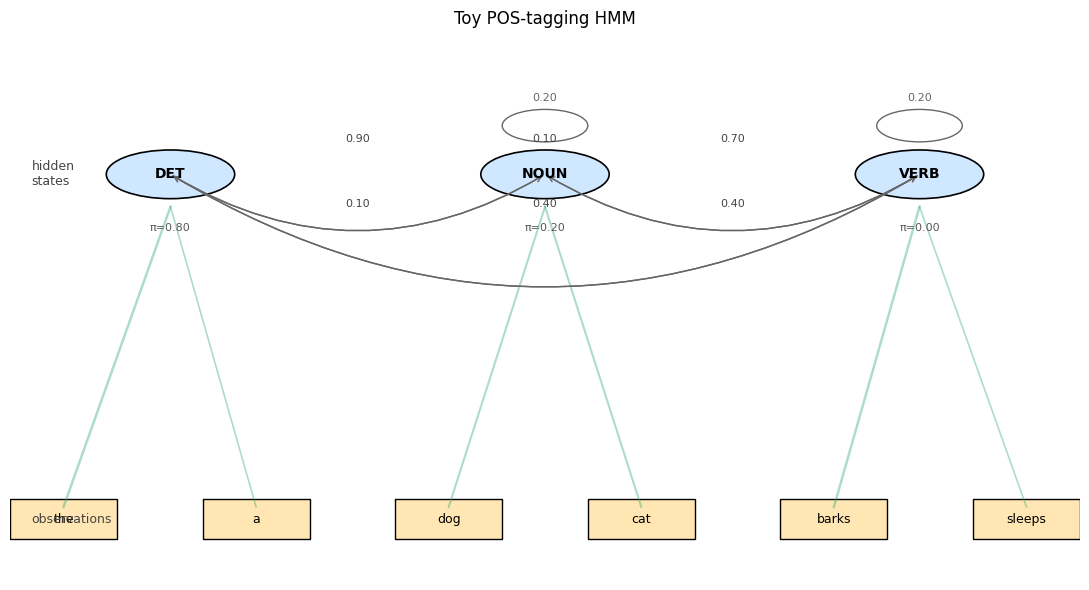

In [ ]:
def draw_hmm(pi, A, B, state_names, obs_names,
             title="HMM (states + emissions)"):
    '''Draw an HMM: hidden-state graph above, emitted observations below.'''
    fig, ax = plt.subplots(figsize=(11, 6))

    N, M = B.shape
    # Place hidden states evenly along y = 1
    state_x = np.linspace(0.15, 0.85, N)
    obs_x   = np.linspace(0.05, 0.95, M)

    # ---- Draw transition arrows between hidden states ----
    for i in range(N):
        for j in range(N):
            if A[i, j] > 0.001:
                if i == j:
                    ax.annotate(
                        f"{A[i,j]:.2f}",
                        xy=(state_x[i], 1.18), ha="center", fontsize=8, color="#666",
                    )
                    ax.add_patch(plt.Circle(
                        (state_x[i], 1.12), 0.04, fill=False, color="#666", lw=1,
                    ))
                else:
                    ax.annotate(
                        "", xy=(state_x[j], 1.0), xytext=(state_x[i], 1.0),
                        arrowprops=dict(
                            arrowstyle="->",
                            connectionstyle=f"arc3,rad={0.3 if i<j else -0.3}",
                            color="#666", lw=1,
                        ),
                    )
                    mx = (state_x[i] + state_x[j]) / 2
                    my = 1.0 + (0.08 if i < j else -0.08)
                    ax.text(mx, my, f"{A[i,j]:.2f}", ha="center", fontsize=8, color="#444")

    # ---- Draw emission lines from each state to its words ----
    for i in range(N):
        for k in range(M):
            if B[i, k] > 0.001:
                ax.plot([state_x[i], obs_x[k]], [0.92, 0.18],
                        color="#3a7", alpha=0.4, lw=B[i, k] * 3)

    # ---- Draw the state nodes (circles) ----
    for i, name in enumerate(state_names):
        ax.add_patch(plt.Circle(
            (state_x[i], 1.0), 0.06, color="#cfe7ff", ec="black", lw=1.2,
        ))
        ax.text(state_x[i], 1.0, name, ha="center", va="center", fontsize=10, fontweight="bold")
        ax.text(state_x[i], 0.86, f"π={pi[i]:.2f}", ha="center", fontsize=8, color="#555")

    # ---- Draw the observation nodes (squares) ----
    for k, name in enumerate(obs_names):
        ax.add_patch(plt.Rectangle(
            (obs_x[k]-0.05, 0.10), 0.10, 0.10, color="#ffe6b3", ec="black", lw=1,
        ))
        ax.text(obs_x[k], 0.15, name, ha="center", va="center", fontsize=9)

    ax.text(0.02, 1.0,  "hidden\nstates",  ha="left", va="center", fontsize=9, color="#444")
    ax.text(0.02, 0.15, "observations",   ha="left", va="center", fontsize=9, color="#444")
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.35)
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_hmm(pi, A, B, tags, vocab, title="Toy POS-tagging HMM")


### Sampling sentences from the HMM

To generate data from an HMM we alternate two steps:

1. **Transition:** draw the next hidden tag from $A$ (or from $\pi$ at $t=0$).
2. **Emission:** draw the word from row $B[q_t]$.

This is the **generative story** the HMM tells about how sentences come into existence: pick a tag, emit a word; pick the next tag conditioned on the previous one, emit a word; and so on.

In [ ]:
def simulate_hmm(pi, A, B, T, rng=None):
    '''Sample (states, observations) of length T from an HMM.'''
    if rng is None:
        rng = np.random.default_rng()
    N, M = B.shape
    states = np.empty(T, dtype=int)
    obs    = np.empty(T, dtype=int)
    states[0] = rng.choice(N, p=pi)
    obs[0]    = rng.choice(M, p=B[states[0]])
    for t in range(1, T):
        states[t] = rng.choice(N, p=A[states[t-1]])
        obs[t]    = rng.choice(M, p=B[states[t]])
    return states, obs


# Sample five sentences of length 4 from the toy HMM.
rng = np.random.default_rng(7)
print("Sampled (tag, word) sequences from the toy HMM:")
for _ in range(5):
    s, o = simulate_hmm(pi, A, B, T=4, rng=rng)
    tag_seq  = " ".join(f"{tags[ti]:>4s}" for ti in s)
    word_seq = " ".join(f"{vocab[wi]:>6s}" for wi in o)
    print(f"  tags : {tag_seq}")
    print(f"  words: {word_seq}\n")


Sampled (tag, word) sequences from the toy HMM:
  tags :  DET NOUN VERB  DET
  words:      a    dog sleeps      a

  tags :  DET NOUN NOUN VERB
  words:    the    dog    dog  barks

  tags : NOUN VERB  DET NOUN
  words:    cat sleeps    the    dog

  tags :  DET NOUN VERB NOUN
  words:    the    cat  barks    dog

  tags :  DET NOUN VERB VERB
  words:    the    dog  barks  barks



## 4. The three fundamental problems, in NLP terms

Following Rabiner's classic 1989 tutorial, three questions cover essentially everything you'd want to do with an HMM. Each one corresponds to a concrete NLP task:

| # | Name | Given | Find | Concrete NLP use |
|---|------|-------|------|------------------|
| 1 | **Likelihood (Evaluation)** | $\lambda$, observation seq. $O$ | $P(O \mid \lambda)$ | language ID; sentence scoring; spam vs. ham |
| 2 | **Decoding** | $\lambda$, $O$ | best hidden seq. $X^*$ | **POS tagging**; NER; speech recognition |
| 3 | **Learning** | observations $O$ (and $N$, $M$) | $\lambda^* = (A, B, \pi)$ | **training the tagger** (supervised or unsupervised) |

The next sections solve them in order. Pay particular attention to **Problem 2** — Viterbi decoding is what most NLP people mean when they say "the HMM algorithm".


## 5. Problem 1 — Likelihood: the Forward algorithm

We want $P(O \mid \lambda)$ for an observation sequence (a sentence) $O = (O_0, O_1, \dots, O_{T-1})$.

In NLP, this is exactly the question: *how plausible is this sentence under our model?* You'd use it for:

- **Language identification.** Train one HMM per language; the language with the highest $P(O\mid\lambda)$ wins.
- **Sentence-level anomaly detection** — phishing, spam, OCR errors.
- **Confidence scoring** for downstream pipelines.

### The naïve view (don't actually do this)

We could sum over **every possible** hidden state sequence $X = (x_0, \dots, x_{T-1})$:

$$
P(O \mid \lambda) \;=\; \sum_{X} P(O, X \mid \lambda) \;=\; \sum_{X} \pi_{x_0}\, b_{x_0}(O_0)\, a_{x_0,x_1}\, b_{x_1}(O_1)\, \cdots\, a_{x_{T-2},x_{T-1}}\, b_{x_{T-1}}(O_{T-1}).
$$

There are $N^T$ such sequences — for an English POS tagger with $N \approx 45$ tags and $T = 30$ words, that's $\sim 10^{49}$ terms. Forget it.

### The clever view: the **Forward** recursion

Define the **forward variable**
$$
\alpha_t(i) \;=\; P(O_0, O_1, \dots, O_t,\; x_t = q_i \mid \lambda),
$$
the joint probability of the observations *up to* time $t$ AND being in state $i$ at time $t$.

Then $\alpha$ obeys a simple recurrence:

$$
\begin{aligned}
\text{Init:}\qquad & \alpha_0(i) = \pi_i\, b_i(O_0) \\
\text{Recurse:}\qquad & \alpha_t(i) = \Bigl[\sum_{j=0}^{N-1} \alpha_{t-1}(j)\, a_{ji}\Bigr]\, b_i(O_t) \\
\text{Terminate:}\qquad & P(O \mid \lambda) = \sum_{i=0}^{N-1} \alpha_{T-1}(i)
\end{aligned}
$$

This is **dynamic programming**: each cell of the trellis is computed once and reused. Cost: $O(N^2 T)$ multiplications instead of $O(N^T)$.


In [ ]:
def forward(pi, A, B, O):
    '''
    Forward algorithm (no scaling — fine for short sequences).

    Parameters
    ----------
    pi : (N,)   initial state distribution.
    A  : (N, N) transition matrix.
    B  : (N, M) emission matrix.
    O  : (T,)   observation sequence (integer indices into B's columns).

    Returns
    -------
    alpha : (T, N) forward probabilities.
    pO    : float — the total likelihood P(O | lambda) = sum_i alpha[T-1, i].
    '''
    T = len(O)
    N = A.shape[0]
    alpha = np.zeros((T, N))

    # Initialisation: alpha_0(i) = pi_i * b_i(O_0)
    alpha[0] = pi * B[:, O[0]]

    # Recursion: alpha_t(i) = (sum_j alpha_{t-1}(j) * A[j,i]) * b_i(O_t)
    # Vectorised: alpha[t-1] @ A gives sum_j alpha[t-1,j] * A[j,i] for each i.
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, O[t]]

    pO = alpha[-1].sum()
    return alpha, pO


# Score the sentence "the dog barks" under the toy HMM.
sentence = ["the", "dog", "barks"]
O = np.array([word2idx[w] for w in sentence])
alpha, pO = forward(pi, A, B, O)

print(f"Sentence: {' '.join(sentence)}")
print(f"\nForward variables alpha[t, i]:")
print(f"  rows = time steps (one per word), cols = tags {tags}")
print(alpha)
print(f"\nP(sentence | lambda) = {pO:.6f}")


Sentence: the dog barks

Forward variables alpha[t, i]:
  rows = time steps (one per word), cols = tags ['DET', 'NOUN', 'VERB']
[[0.48   0.     0.    ]
 [0.     0.216  0.    ]
 [0.     0.     0.0907]]

P(sentence | lambda) = 0.090720


**Sanity check.** For such a short sentence we can verify the forward algorithm by brute-forcing the sum over all $N^T$ tag sequences.

In [ ]:
from itertools import product

def brute_force_likelihood(pi, A, B, O):
    '''Verify forward by enumerating all N**T tag sequences. Tiny T only.'''
    T, N = len(O), A.shape[0]
    total = 0.0
    for X in product(range(N), repeat=T):
        p = pi[X[0]] * B[X[0], O[0]]
        for t in range(1, T):
            p *= A[X[t-1], X[t]] * B[X[t], O[t]]
        total += p
    return total

p_brute = brute_force_likelihood(pi, A, B, O)
print(f"Forward     P(O|lambda) = {pO:.8f}")
print(f"Brute force P(O|lambda) = {p_brute:.8f}")
print("Match!" if np.isclose(pO, p_brute) else "MISMATCH")


Forward     P(O|lambda) = 0.09072000
Brute force P(O|lambda) = 0.09072000
Match!


### The Backward algorithm (we'll need it for unsupervised learning)

The mirror image of $\alpha$ is the **backward variable**:
$$
\beta_t(i) \;=\; P(O_{t+1}, O_{t+2}, \dots, O_{T-1} \mid x_t = q_i,\, \lambda).
$$
That is, $\beta_t(i)$ is the probability of the *future* observations given that we are in state $i$ at time $t$.

$$
\begin{aligned}
\text{Init:}\qquad     & \beta_{T-1}(i) = 1 \\
\text{Recurse:}\qquad  & \beta_t(i) = \sum_{j=0}^{N-1} a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j),\quad t = T-2, \dots, 0
\end{aligned}
$$

We don't strictly need $\beta$ for evaluation, but it is essential for **Baum–Welch** (section 9).


In [ ]:
def backward(A, B, O):
    '''Backward algorithm. Returns beta[t, i] = P(O_{t+1..T-1} | x_t=i).'''
    T, N = len(O), A.shape[0]
    beta = np.zeros((T, N))
    beta[-1] = 1.0
    for t in range(T - 2, -1, -1):
        beta[t] = A @ (B[:, O[t+1]] * beta[t+1])
    return beta


beta = backward(A, B, O)
print("Backward variables beta[t, i]:")
print(beta)

# Cross-check: P(O | lambda) = sum_i alpha[t, i] * beta[t, i] at any time t.
p_check = (alpha[0] * beta[0]).sum()
print(f"\nP(O|lambda) via forward only        = {pO:.6f}")
print(f"P(O|lambda) via alpha*beta at t = 0 = {p_check:.6f}")


Backward variables beta[t, i]:
[[0.189 0.042 0.084]
 [0.06  0.42  0.12 ]
 [1.    1.    1.   ]]

P(O|lambda) via forward only        = 0.090720
P(O|lambda) via alpha*beta at t = 0 = 0.090720


## 6. Problem 2 — Decoding: Viterbi *is* the POS tagger

This is the section that matters most for NLP.

We want the **most likely hidden state sequence** that explains the observations:
$$
X^{*} \;=\; \arg\max_{X}\; P(X \mid O, \lambda) \;=\; \arg\max_{X}\; P(X, O \mid \lambda).
$$

**For POS tagging this is exactly the inference problem:** given a sentence $\mathbf{w}$ and a trained HMM, output the tag sequence $\mathbf{t}^*$ that best explains the words.

The trick is the same as in the forward algorithm — but we replace **sum** with **max**, and we keep **back-pointers** so we can reconstruct the winning path.

Define
$$
v_t(j) \;=\; \max_{x_0, \dots, x_{t-1}}\; P(x_0, \dots, x_{t-1}, O_0, \dots, O_t,\; x_t = q_j \mid \lambda).
$$

Then:

$$
\begin{aligned}
\text{Init:}\qquad     & v_0(j) = \pi_j\, b_j(O_0) \\
\text{Recurse:}\qquad  & v_t(j) = \max_{i}\; v_{t-1}(i)\, a_{ij}\, b_j(O_t) \\
                       & \text{bp}_t(j) = \arg\max_{i}\; v_{t-1}(i)\, a_{ij}\, b_j(O_t) \\
\text{Terminate:}\qquad& P^{*} = \max_{i} v_{T-1}(i),\quad x^{*}_{T-1} = \arg\max_{i} v_{T-1}(i)
\end{aligned}
$$

Then **back-trace** through the $\text{bp}$ pointers to recover $X^*$.

### Numerical note: work in log-space

Because we're chaining many small probabilities together, $v_t(j)$ shrinks exponentially. The standard fix is to take logs:
$$
\hat v_t(j) \;=\; \max_i \bigl[\hat v_{t-1}(i) + \log a_{ij}\bigr] + \log b_j(O_t).
$$
Sums of logs are numerically safe — multiplications of tiny floats are not.


In [ ]:
def viterbi(pi, A, B, O):
    '''
    Viterbi decoding in log-space (avoids underflow on long sentences).

    Returns
    -------
    best_path : (T,) array — the most likely hidden state sequence.
    best_logp : float    — log P(X*, O | lambda) for that path.
    log_v     : (T, N)   — log-Viterbi values (useful for plotting).
    '''
    T, N = len(O), A.shape[0]

    # tiny epsilon to avoid log(0) when probabilities are exactly zero.
    EPS = 1e-300
    log_pi = np.log(pi + EPS)
    log_A  = np.log(A  + EPS)
    log_B  = np.log(B  + EPS)

    log_v = np.full((T, N), -np.inf)
    bp    = np.zeros((T, N), dtype=int)

    # Initialisation
    log_v[0] = log_pi + log_B[:, O[0]]

    # Recursion
    for t in range(1, T):
        # scores[i, j] = log_v[t-1, i] + log_A[i, j]
        scores = log_v[t-1, :, None] + log_A   # broadcasting: (N, 1) + (N, N) -> (N, N)
        bp[t]    = np.argmax(scores, axis=0)
        log_v[t] = np.max(scores,    axis=0) + log_B[:, O[t]]

    # Termination + back-trace
    best_logp = log_v[-1].max()
    best_path = np.empty(T, dtype=int)
    best_path[-1] = log_v[-1].argmax()
    for t in range(T - 2, -1, -1):
        best_path[t] = bp[t+1, best_path[t+1]]
    return best_path, best_logp, log_v


# Tag the sentence "the dog barks"
best_path, best_logp, log_v = viterbi(pi, A, B, O)

print(f"Sentence  : {' '.join(sentence)}")
print(f"Best tags : {' '.join(tags[t] for t in best_path)}")
print(f"log P(X*, O | lambda) = {best_logp:.4f}")
print(f"P(X*, O | lambda)     = {np.exp(best_logp):.6f}")


Sentence  : the dog barks
Best tags : DET NOUN VERB
log P(X*, O | lambda) = -2.4000
P(X*, O | lambda)     = 0.090720


### Visualising the Viterbi trellis

The Viterbi trellis makes the recursion very tangible: each column is a time step (a word), each row is a tag, and each cell shows $\log v_t(\text{tag})$.

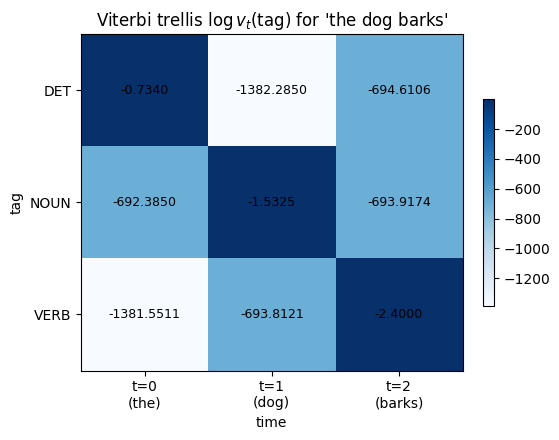

In [ ]:
def plot_trellis(values, state_names, obs_names, title, fmt="{:.4f}"):
    '''Plot a (T, N) DP table as a labelled grid.'''
    T, N = values.shape
    fig, ax = plt.subplots(figsize=(1.4*T + 1.5, 1.0*N + 1.5))
    im = ax.imshow(values.T, cmap="Blues", aspect="auto")
    ax.set_xticks(range(T))
    ax.set_xticklabels([f"t={t}\n({obs_names[t]})" for t in range(T)])
    ax.set_yticks(range(N))
    ax.set_yticklabels(state_names)
    ax.set_xlabel("time")
    ax.set_ylabel("tag")
    ax.set_title(title)
    for t in range(T):
        for i in range(N):
            ax.text(
                t, i, fmt.format(values[t, i]),
                ha="center", va="center", fontsize=9,
                color="black" if values[t, i] < values.max() * 0.6 else "white",
            )
    fig.colorbar(im, ax=ax, fraction=0.025)
    plt.tight_layout()
    plt.show()


plot_trellis(
    log_v, tags, sentence,
    title=r"Viterbi trellis $\log v_t(\mathrm{tag})$ for 'the dog barks'",
)


**Key observation.** Notice how the trellis lights up only at the "right" cell at each time step: DET at $t=0$, NOUN at $t=1$, VERB at $t=2$. That's because in our toy HMM the emission matrix is essentially deterministic — every word can only be emitted by one tag, so the tagger has no real ambiguity to resolve.

**Real POS tagging is harder.** Words like *book* (noun *or* verb), *flies* (noun *or* verb), *that* (DET *or* PRON *or* SCONJ) have multiple plausible tags, and the Viterbi algorithm uses **context** (the transition probabilities $A$) to pick the right one. We'll see this in section 8 on the Brown corpus.

### Two notions of "best": Viterbi vs. posterior

There are two reasonable definitions of the *best* tag sequence:

- **Viterbi (joint-MAP):** the *single* sequence with highest joint probability $P(X, O \mid \lambda)$.
- **Posterior (marginal-MAP):** at each $t$, pick the tag with highest *marginal* posterior $\gamma_t(i) = P(x_t = i \mid O, \lambda)$.

These can disagree (Stamp gives a worked example). For POS tagging the Viterbi version is overwhelmingly the standard choice because it guarantees a *consistent* tag sequence — never one that contains a tag transition with probability zero. The marginal version maximises per-position accuracy but may produce inconsistent sequences.


## 7. Problem 3a — Supervised learning: MLE from a tagged corpus

So far we've been *given* the HMM parameters $\lambda = (A, B, \pi)$. In practice we have to learn them from data. There are two scenarios:

| Scenario | Data we have | Algorithm |
|---|---|---|
| **Supervised** | sentences *with* gold tags | maximum-likelihood counting (this section) |
| **Unsupervised** | sentences *without* tags | Baum–Welch / EM (section 9) |

For POS tagging we usually have a **tagged corpus** (Penn Treebank, Brown with manual annotations, Universal Dependencies, …). In that case training an HMM is just **counting and normalising**:

$$
\hat\pi_i = \frac{C(t_1 = i)}{\#\text{sentences}},\qquad
\hat a_{ij} = \frac{C(t_{k-1}=i,\, t_k=j)}{C(t_{k-1}=i)},\qquad
\hat b_i(w) = \frac{C(t_k=i,\, w_k=w)}{C(t_k=i)}.
$$

In words:

- $\pi_i$ is the fraction of sentences that **start** with tag $i$.
- $a_{ij}$ is the fraction of times tag $i$ is **followed by** tag $j$.
- $b_i(w)$ is the fraction of times tag $i$ **emits** the word $w$.

This is just a **bigram model over tags**, plus a unigram emission model for words conditioned on tags.

### Smoothing: handling unseen events

A pure MLE estimate assigns probability **zero** to anything not seen in training. For POS tagging that's fatal:

- A test sentence might contain a word never seen in training (an **OOV**, out-of-vocabulary, word). $\hat b_i(w) = 0$ for *all* tags $i$, so the model can't tag it.
- A test sentence might contain a tag bigram never seen in training, e.g. `INTJ -> SCONJ`. $\hat a_{ij} = 0$ kills the whole sentence's likelihood.

The standard fixes:

- **Add-one (Laplace) smoothing** for transitions and emissions:  $\hat a_{ij} = \frac{C(i,j) + 1}{C(i) + N}$.
- **OOV handling.** A common trick is to assign every tag a small uniform emission probability for unknown words. More sophisticated methods use word suffixes, capitalisation, etc.

The implementation below does both.


In [ ]:
def train_hmm_supervised(tagged_sentences, alpha_smooth=0.01):
    '''
    Train an HMM from a list of tagged sentences via MLE with add-alpha smoothing.

    Parameters
    ----------
    tagged_sentences : list of list of (word, tag) tuples.
    alpha_smooth     : float — smoothing constant (alpha=1 is Laplace; smaller is gentler).

    Returns
    -------
    pi, A, B   : numpy arrays of the right shapes.
    tag2idx, word2idx : dictionaries mapping symbols to row/column indices.
    '''
    # ----- Pass 1: collect the tag and word vocabularies -----
    tag_set  = set()
    word_set = set()
    for sent in tagged_sentences:
        for w, t in sent:
            tag_set.add(t)
            word_set.add(w)

    # Sorted lists give us a canonical, reproducible ordering.
    tag_list  = sorted(tag_set)
    word_list = sorted(word_set)
    tag2idx   = {t: i for i, t in enumerate(tag_list)}
    word2idx  = {w: i for i, w in enumerate(word_list)}
    N, M = len(tag_list), len(word_list)

    # ----- Pass 2: count -----
    # Initialise count tables with the smoothing constant alpha (so every entry > 0).
    pi_counts = np.full(N,         alpha_smooth)
    A_counts  = np.full((N, N),    alpha_smooth)
    B_counts  = np.full((N, M),    alpha_smooth)

    for sent in tagged_sentences:
        prev_t = None
        for k, (w, t) in enumerate(sent):
            ti, wi = tag2idx[t], word2idx[w]
            if k == 0:
                pi_counts[ti] += 1                   # initial-tag count
            else:
                A_counts[prev_t, ti] += 1            # transition count
            B_counts[ti, wi] += 1                    # emission count
            prev_t = ti

    # ----- Normalise rows to get probabilities -----
    pi = pi_counts / pi_counts.sum()
    A  = A_counts  / A_counts.sum(axis=1, keepdims=True)
    B  = B_counts  / B_counts.sum(axis=1, keepdims=True)

    return pi, A, B, tag2idx, word2idx, tag_list, word_list


# ----- Demo on a 6-sentence toy POS corpus -----
toy_train = [
    [("the", "DET"), ("dog", "NOUN"), ("barks", "VERB")],
    [("a", "DET"),   ("cat", "NOUN"), ("sleeps", "VERB")],
    [("the", "DET"), ("cat", "NOUN"), ("barks", "VERB")],
    [("a", "DET"),   ("dog", "NOUN"), ("sleeps", "VERB")],
    [("the", "DET"), ("dog", "NOUN"), ("sleeps", "VERB")],
    [("a", "DET"),   ("cat", "NOUN"), ("barks", "VERB")],
]

pi_s, A_s, B_s, t2i, w2i, tag_list, word_list = train_hmm_supervised(toy_train,
                                                                     alpha_smooth=0.01)

print(f"Tags:  {tag_list}")
print(f"Words: {word_list}")
print(f"\npi (initial tag distribution):\n{pi_s}")
print(f"\nA (tag transitions):\n{A_s}")
print(f"\nB (word emissions per tag):\n{B_s}")


Tags:  ['DET', 'NOUN', 'VERB']
Words: ['a', 'barks', 'cat', 'dog', 'sleeps', 'the']

pi (initial tag distribution):
[0.9967 0.0017 0.0017]

A (tag transitions):
[[0.0017 0.9967 0.0017]
 [0.0017 0.0017 0.9967]
 [0.3333 0.3333 0.3333]]

B (word emissions per tag):
[[0.4967 0.0017 0.0017 0.0017 0.0017 0.4967]
 [0.0017 0.0017 0.4967 0.4967 0.0017 0.0017]
 [0.0017 0.4967 0.0017 0.0017 0.4967 0.0017]]


Notice that `pi` puts almost all mass on `DET` (every training sentence starts with `the` or `a`), `A` says `DET → NOUN → VERB` is the only realistic path, and `B` neatly separates words by part of speech. The tiny `0.01` smoothing prevents any entry from being exactly zero, which would crash Viterbi on unseen events.

Now let's tag a *new* sentence with the supervised model — a sentence the trainer never saw:

In [ ]:
def tag_sentence(words, pi, A, B, tag2idx, word2idx, tag_list, oov_logprob=-15.0):
    '''
    Run Viterbi on a sentence (a list of word strings) and return the predicted tags.

    OOV (unknown) words are handled by giving every tag a fixed log-probability
    `oov_logprob` for that word (i.e. uniform across tags — context decides).
    '''
    T = len(words)
    N = A.shape[0]

    # Build observation log-probs column for each word: log_b[t, i] = log P(word_t | tag_i)
    log_b = np.full((T, N), oov_logprob)
    for t, w in enumerate(words):
        if w in word2idx:
            wi = word2idx[w]
            log_b[t] = np.log(B[:, wi] + 1e-300)
        # else: leave as oov_logprob -> uniform across tags

    # Viterbi in log space
    log_pi = np.log(pi + 1e-300)
    log_A  = np.log(A  + 1e-300)
    log_v  = np.full((T, N), -np.inf)
    bp     = np.zeros((T, N), dtype=int)

    log_v[0] = log_pi + log_b[0]
    for t in range(1, T):
        scores = log_v[t-1, :, None] + log_A     # (N, N)
        bp[t]    = np.argmax(scores, axis=0)
        log_v[t] = np.max(scores,    axis=0) + log_b[t]

    path = np.empty(T, dtype=int)
    path[-1] = log_v[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = bp[t+1, path[t+1]]
    return [tag_list[p] for p in path]


# Tag two sentences:
for sent in [["the", "dog", "sleeps"],
             ["a", "cat", "barks"],
             ["the", "elephant", "sleeps"]]:   # 'elephant' is OOV!
    pred = tag_sentence(sent, pi_s, A_s, B_s, t2i, w2i, tag_list)
    line = "  ".join(f"{w}/{t}" for w, t in zip(sent, pred))
    print(line)


the/DET  dog/NOUN  sleeps/VERB
a/DET  cat/NOUN  barks/VERB
the/DET  elephant/NOUN  sleeps/VERB


On the third sentence, the word `elephant` was never seen in training. Because we treat every tag as equally likely to emit an unknown word, the **transition probabilities** alone decide its tag — and the model correctly assigns NOUN, because that's by far the most likely tag between DET and VERB. This is the HMM at its most useful: **using context to disambiguate**.

## 8. A real experiment — POS tagging the Brown corpus

Time to leave toyland. We'll train an HMM POS tagger on a real annotated corpus — NLTK's [Brown corpus](https://www.nltk.org/book/ch02.html) with the Universal Tagset (12 coarse tags: NOUN, VERB, ADJ, ADV, DET, ...). This is small by modern standards (~57k sentences) but plenty to demonstrate the method.

We'll:

1. Load Brown sentences with their universal POS tags.
2. Split into 80% train / 20% test.
3. Train an HMM via supervised MLE (the function from section 7).
4. Tag the test sentences with Viterbi.
5. Measure word-level tagging accuracy.
6. Inspect a few example sentences and look at confusions.


In [ ]:
# ---- Load Brown sentences with the universal tagset ----
from nltk.corpus import brown

# brown.tagged_sents(tagset='universal') returns sentences as lists of (word, tag) pairs.
# Lower-casing words is a common simple normalisation step.
all_sents = [
    [(w.lower(), t) for (w, t) in sent]
    for sent in brown.tagged_sents(tagset="universal")
]

print(f"Total sentences: {len(all_sents):,}")
print(f"Total tokens   : {sum(len(s) for s in all_sents):,}")
print(f"\nFirst sentence (first 10 tokens):")
print(all_sents[0][:10])


Total sentences: 57,340
Total tokens   : 1,161,192

First sentence (first 10 tokens):
[('the', 'DET'), ('fulton', 'NOUN'), ('county', 'NOUN'), ('grand', 'ADJ'), ('jury', 'NOUN'), ('said', 'VERB'), ('friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP')]


In [ ]:
# ---- 80 / 20 train/test split (deterministic) ----
import random
random.seed(0)
shuffled = all_sents[:]                 # copy
random.shuffle(shuffled)
split = int(0.8 * len(shuffled))
train_sents = shuffled[:split]
test_sents  = shuffled[split:]

print(f"Train sentences: {len(train_sents):,}  ({sum(len(s) for s in train_sents):,} tokens)")
print(f"Test  sentences: {len(test_sents):,}  ({sum(len(s) for s in test_sents):,} tokens)")


Train sentences: 45,872  (929,718 tokens)
Test  sentences: 11,468  (231,474 tokens)


In [ ]:
# ---- Train ----
pi_b, A_b, B_b, t2i_b, w2i_b, tag_list_b, word_list_b = train_hmm_supervised(
    train_sents, alpha_smooth=0.01,
)
print(f"Tagset ({len(tag_list_b)} tags): {tag_list_b}")
print(f"Vocabulary size: {len(word_list_b):,} words")


Tagset (12 tags): ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
Vocabulary size: 44,972 words


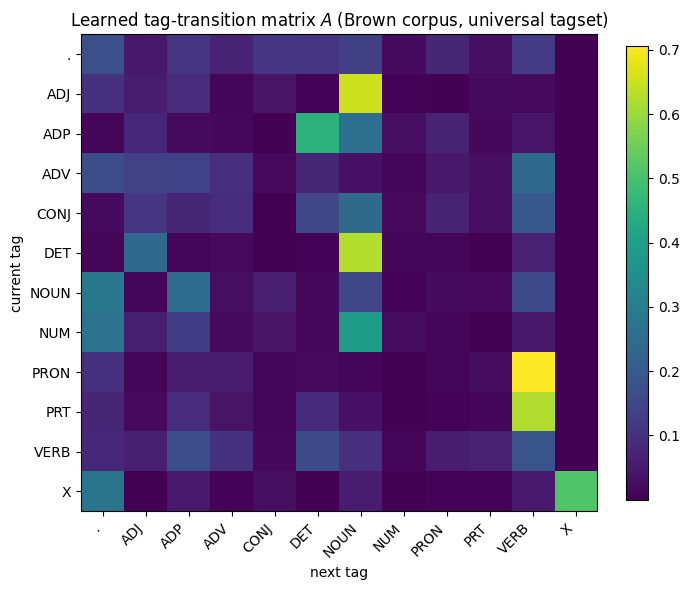

In [ ]:
# Have a quick look at the learned tag-transition matrix.
# We display A_b as a heatmap — the diagonal-ish patterns reveal a lot of English syntax.
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(A_b, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(tag_list_b))); ax.set_xticklabels(tag_list_b, rotation=45, ha="right")
ax.set_yticks(range(len(tag_list_b))); ax.set_yticklabels(tag_list_b)
ax.set_xlabel("next tag"); ax.set_ylabel("current tag")
ax.set_title("Learned tag-transition matrix $A$ (Brown corpus, universal tagset)")
fig.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()


Look at this matrix carefully — it is a **visual summary of English syntax**, learned automatically from counts. You should see:

- Bright cells in the `DET → NOUN`, `ADJ → NOUN`, `NOUN → VERB`, `ADP → DET` rows — exactly the canonical phrase structure.
- A bright `.` (PUNCT) row that mostly transitions back to sentence-initial-ish tags.
- A near-zero `DET → DET` cell — you don't normally see two determiners in a row.


In [ ]:
# ---- Evaluate ----
def evaluate_tagger(test_sents, pi, A, B, tag2idx, word2idx, tag_list,
                   oov_logprob=-15.0, max_eval=None):
    '''Tag every test sentence and return overall word-level accuracy.'''
    correct = 0
    total   = 0
    confusion = Counter()
    for sent in (test_sents[:max_eval] if max_eval else test_sents):
        words      = [w for (w, _) in sent]
        gold_tags  = [t for (_, t) in sent]
        pred_tags  = tag_sentence(words, pi, A, B, tag2idx, word2idx, tag_list,
                                  oov_logprob=oov_logprob)
        for g, p in zip(gold_tags, pred_tags):
            total += 1
            if g == p:
                correct += 1
            else:
                confusion[(g, p)] += 1
    return correct / total, confusion


acc, confusion = evaluate_tagger(test_sents, pi_b, A_b, B_b,
                                 t2i_b, w2i_b, tag_list_b)
print(f"Word-level tagging accuracy on test set: {acc*100:.2f}%")

# Top 10 confusions
print("\nTop tag confusions  (gold -> predicted : count):")
for (g, p), c in confusion.most_common(10):
    print(f"  {g:>5s} -> {p:<5s} : {c}")


Word-level tagging accuracy on test set: 95.93%

Top tag confusions  (gold -> predicted : count):
   VERB -> NOUN  : 1172
   NOUN -> ADJ   : 753
   NOUN -> VERB  : 699
    ADJ -> ADV   : 473
    ADJ -> NOUN  : 471
    PRT -> ADP   : 461
    ADV -> ADJ   : 449
   NOUN -> .     : 421
    ADP -> ADV   : 407
    ADV -> ADP   : 355


You should see an accuracy in the **mid-90s** — typically 92–96% depending on the smoothing setting. State-of-the-art neural taggers reach ~98%, so a simple HMM gets you most of the way there for almost no compute. (This is why HMM-based taggers were standard in NLP pipelines for two decades.)

The most common confusions are linguistically reasonable: NOUN ↔ VERB (because of word ambiguity like *runs*, *book*) and NOUN ↔ ADJ (because adjectives often modify nouns and the boundary is fuzzy).


In [ ]:
# ---- Tag a few example sentences and show the predictions side by side with the gold tags ----
print("Sample taggings (✔ = correct, ✘ = wrong):\n")
for sent in test_sents[:3]:
    words     = [w for (w, _) in sent]
    gold_tags = [t for (_, t) in sent]
    pred_tags = tag_sentence(words, pi_b, A_b, B_b, t2i_b, w2i_b, tag_list_b)
    rows = []
    for w, g, p in zip(words, gold_tags, pred_tags):
        mark = "✔" if g == p else "✘"
        rows.append(f"{w}/{p}{mark}({g})")
    print("  " + "  ".join(rows))
    print()


Sample taggings (✔ = correct, ✘ = wrong):

  ``/.✔(.)  it's/PRT✔(PRT)  parked/VERB✔(VERB)  in/ADP✔(ADP)  front/NOUN✔(NOUN)  ''/.✔(.)  ./.✔(.)

  the/DET✔(DET)  commission/NOUN✔(NOUN)  had/VERB✔(VERB)  issued/VERB✔(VERB)  an/DET✔(DET)  administrative/ADJ✔(ADJ)  order/NOUN✔(NOUN)  which/DET✔(DET)  was/VERB✔(VERB)  challenged/VERB✔(VERB)  as/ADP✔(ADP)  discriminatory/ADJ✔(ADJ)  against/ADP✔(ADP)  negroes/NOUN✔(NOUN)  ./.✔(.)

  the/DET✔(DET)  radiation/NOUN✔(NOUN)  doses/NOUN✔(NOUN)  required/VERB✔(VERB)  for/ADP✔(ADP)  the/DET✔(DET)  preservation/NOUN✔(NOUN)  of/ADP✔(ADP)  foods/NOUN✔(NOUN)  are/VERB✔(VERB)  in/ADP✔(ADP)  the/DET✔(DET)  following/VERB✔(VERB)  ranges/NOUN✔(NOUN)  :/.✔(.)  1/NUM✔(NUM)  ./.✔(.)



## 9. Problem 3b — Unsupervised learning: Baum–Welch

The supervised setup of section 7 needs a tagged corpus. What if we *only* have raw text? Can we still learn an HMM?

This is the **Baum–Welch** (or **Forward–Backward**) algorithm — the EM (expectation-maximisation) recipe for HMMs.

> Iteratively **guess soft state assignments** ($\gamma$ and $\xi$) using the current parameters, then **re-estimate** parameters as if those soft assignments were true.

### Two new quantities

The **state-occupancy** (gamma):
$$
\gamma_t(i) \;=\; P(x_t = q_i \mid O, \lambda) \;=\; \frac{\alpha_t(i)\,\beta_t(i)}{P(O \mid \lambda)}.
$$

The **state-pair / transition** (xi, sometimes called the "di-gamma"):
$$
\xi_t(i, j) \;=\; P(x_t = q_i,\, x_{t+1} = q_j \mid O, \lambda) \;=\; \frac{\alpha_t(i)\, a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j)}{P(O \mid \lambda)}.
$$

Note that $\gamma_t(i) = \sum_j \xi_t(i, j)$ — they are consistent.

### Re-estimation formulas (the M-step)

$$
\begin{aligned}
\hat\pi_i      &= \gamma_0(i) \\[4pt]
\hat a_{ij}    &= \dfrac{\sum_{t=0}^{T-2} \xi_t(i, j)}{\sum_{t=0}^{T-2} \gamma_t(i)}
                  \quad \text{(expected }i\!\to\!j\text{ transitions / expected times in }i\text{)} \\[8pt]
\hat b_j(k)    &= \dfrac{\sum_{t:\, O_t = k}\, \gamma_t(j)}{\sum_{t=0}^{T-1} \gamma_t(j)}
                  \quad \text{(expected times in }j\text{ emitting }k\text{ / expected times in }j\text{)}
\end{aligned}
$$

Compare these with the **counting** estimators in section 7. They look almost identical — except that the supervised estimator counts **observed** transitions, and Baum–Welch counts **expected** transitions under the current model. EM is just "supervised training, but with soft labels we re-compute every iteration".

### Numerical stability: scaling

Both $\alpha_t(i)$ and $\beta_t(i)$ shrink toward $0$ exponentially fast in $T$. Without re-scaling they'll underflow to $0$ on any sequence longer than a few dozen steps. The standard fix (Stamp §6) is to rescale $\alpha_t$ at every step so it sums to 1, and use the **same** scale factors on $\beta_t$. The re-estimation formulas come out unchanged, and $\log P(O\mid\lambda) = -\sum_t \log c_t$.


In [ ]:
def forward_scaled(pi, A, B, O):
    '''Scaled forward. Returns alpha_hat (T,N) and scale factors c (T,).
       sum_i alpha_hat[t,i] = 1 for every t,
       and  log P(O|lambda) = -sum_t log c_t.
    '''
    T, N = len(O), A.shape[0]
    alpha = np.zeros((T, N))
    c     = np.zeros(T)

    alpha[0] = pi * B[:, O[0]]
    c[0]     = 1.0 / alpha[0].sum()
    alpha[0] *= c[0]

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, O[t]]
        c[t]     = 1.0 / alpha[t].sum()
        alpha[t] *= c[t]
    return alpha, c


def backward_scaled(A, B, O, c):
    '''Scaled backward — uses the SAME scale factors c[t] from forward_scaled.'''
    T, N = len(O), A.shape[0]
    beta = np.zeros((T, N))
    beta[-1] = c[-1]
    for t in range(T - 2, -1, -1):
        beta[t] = A @ (B[:, O[t+1]] * beta[t+1])
        beta[t] *= c[t]
    return beta


def baum_welch(O, N, M, n_iter=100, tol=1e-4, seed=0, verbose=False):
    '''
    Baum–Welch (EM) training for an HMM with N hidden states and M observation
    symbols, given a single observation sequence O.

    Returns the learned (pi, A, B) and the list of log-likelihoods per iteration.
    '''
    rng = np.random.default_rng(seed)
    T   = len(O)

    # ---- Random near-uniform initialisation (NOT exactly uniform — that's a
    # stationary point of EM and the model would be stuck there forever) ----
    pi = rng.dirichlet(np.ones(N))
    A  = rng.dirichlet(np.ones(N), size=N)
    B  = rng.dirichlet(np.ones(M), size=N)

    log_likelihoods = []

    for it in range(n_iter):
        # ===== E-step =====
        alpha, c = forward_scaled(pi, A, B, O)
        beta     = backward_scaled(A, B, O, c)
        log_p    = -np.sum(np.log(c))         # log P(O | lambda)
        log_likelihoods.append(log_p)

        # gamma[t,i] = alpha_hat[t,i] * beta_hat[t,i] / c[t]
        gamma = alpha * beta / c[:, None]

        # xi[t,i,j] = alpha_hat[t,i] * A[i,j] * B[j,O[t+1]] * beta_hat[t+1,j]
        # (scale factors cancel cleanly in the M-step ratios)
        xi = np.zeros((T - 1, N, N))
        for t in range(T - 1):
            xi[t] = (alpha[t][:, None]
                     * A
                     * B[:, O[t+1]][None, :]
                     * beta[t+1][None, :])

        # ===== M-step =====
        pi = gamma[0]
        A  = xi.sum(axis=0) / gamma[:-1].sum(axis=0)[:, None]

        new_B = np.zeros((N, M))
        for k in range(M):
            mask = (O == k)
            new_B[:, k] = gamma[mask].sum(axis=0)
        new_B /= gamma.sum(axis=0)[:, None]
        B = new_B

        if verbose and (it < 5 or it % 10 == 0):
            print(f"iter {it:3d}   log P(O|lambda) = {log_p:.4f}")

        # ---- Convergence check ----
        if it > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            if verbose:
                print(f"Converged at iteration {it}.")
            break

    return pi, A, B, log_likelihoods


## 10. Unsupervised structure discovery — vowels vs. consonants

This is the famous experiment from Stamp §8 (originally Cave & Neuwirth 1980), and a striking demonstration of what unsupervised HMM learning can pull from raw text.

The setup:

- Take a body of English text — we'll use a chunk of the Brown corpus.
- Reduce it to **27 symbols**: the 26 lowercase letters plus the space character.
- Train a 2-state HMM ($N = 2$, $M = 27$) with **Baum–Welch** on this raw stream of characters. **No labels.**

What the algorithm "discovers", with no prior knowledge of English: one hidden state emits vowels (and spaces) with high probability, and the other emits consonants. The vowel/consonant distinction is statistically detectable purely from the bigram structure of English, because vowels and consonants tend to alternate (`c-v-c-v-c…`).

This is exactly what an unsupervised POS tag induction algorithm would try to do at the *word* level — except this version is small enough that we can actually run it in a few seconds.


In [ ]:
import string

# Build a single character stream from the first ~3000 Brown sentences.
# (Using the full corpus would also work but takes ~10x longer to train.)
TEXT = " ".join(
    " ".join(w for (w, _) in sent)
    for sent in brown.tagged_sents()[:3000]
)

# Keep only a-z and spaces; collapse runs of whitespace; lowercase.
alphabet = string.ascii_lowercase + " "
char2idx = {c: i for i, c in enumerate(alphabet)}

def text_to_obs(text):
    text = text.lower()
    return np.array([char2idx[c] for c in text if c in char2idx], dtype=int)

O_text = text_to_obs(TEXT)
print(f"Character stream length: T = {len(O_text):,}")
print(f"Alphabet size:           M = {len(alphabet)}")
print(f"\nFirst 100 chars of cleaned text: {''.join(alphabet[i] for i in O_text[:100])!r}")


Character stream length: T = 334,282
Alphabet size:           M = 27

First 100 chars of cleaned text: 'the fulton county grand jury said friday an investigation of atlantas recent primary election produc'


In [ ]:
# Train a 2-state HMM on the raw character stream.
# This typically takes 10-30 seconds depending on the corpus size.
pi_t, A_t, B_t, lls_t = baum_welch(
    O_text, N=2, M=27, n_iter=60, tol=1e-3, seed=2, verbose=False,
)

print(f"Final log P(O|lambda) = {lls_t[-1]:.2f}")
print(f"Iterations run         = {len(lls_t)}")
print(f"\nLearned transition matrix A:\n{A_t}")
print(f"\nLearned initial distribution pi: {pi_t}")


Final log P(O|lambda) = -916532.94
Iterations run         = 60

Learned transition matrix A:
[[0.25   0.75  ]
 [0.7043 0.2957]]

Learned initial distribution pi: [0. 1.]


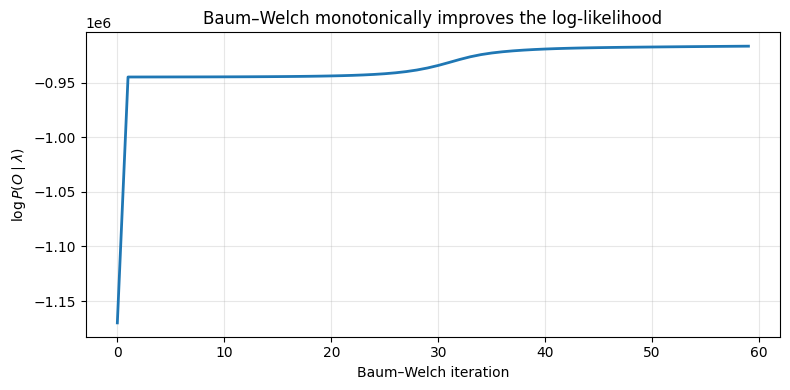

In [ ]:
# Plot the convergence of the log-likelihood
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lls_t, lw=2)
ax.set_xlabel("Baum–Welch iteration")
ax.set_ylabel(r"$\log P(O \mid \lambda)$")
ax.set_title("Baum–Welch monotonically improves the log-likelihood")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


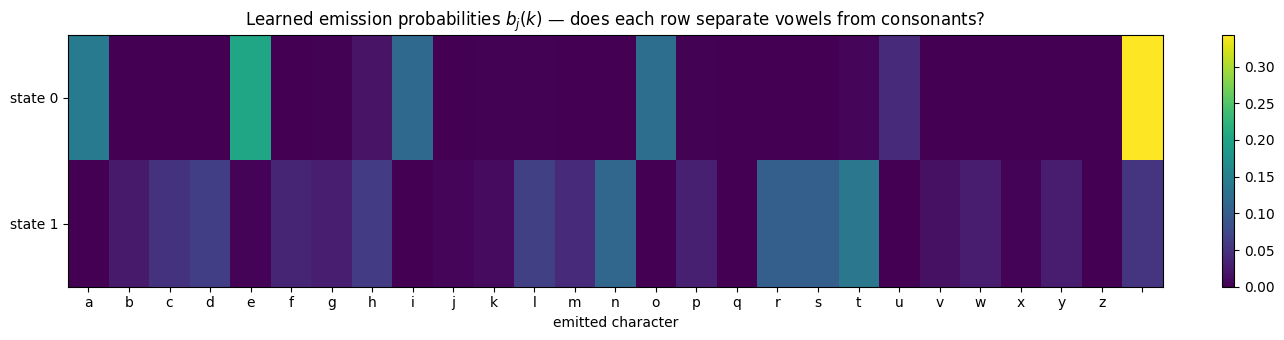


State 0: top-8 characters  ->  _eaoiuht   (probs: [0.344 0.202 0.14  0.124 0.117 0.041 0.018 0.005])
State 1: top-8 characters  ->  tnrsldh_   (probs: [0.136 0.113 0.104 0.103 0.065 0.064 0.061 0.052])


In [ ]:
# Inspect the learned emission matrix B_t.
# If the algorithm rediscovered the vowel/consonant distinction, one row
# will spike on a, e, i, o, u (and space) while the other spikes on consonants.

fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(B_t, cmap="viridis", aspect="auto")
ax.set_yticks([0, 1]); ax.set_yticklabels(["state 0", "state 1"])
ax.set_xticks(range(27)); ax.set_xticklabels(list(alphabet))
ax.set_xlabel("emitted character")
ax.set_title(r"Learned emission probabilities $b_j(k)$ — does each row separate vowels from consonants?")
fig.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout(); plt.show()

# Print the top emissions of each state for clarity
print()
for j in range(2):
    top = np.argsort(B_t[j])[::-1][:8]
    chars = "".join(alphabet[k] if alphabet[k] != " " else "_" for k in top)
    print(f"State {j}: top-8 characters  ->  {chars}   "
          f"(probs: {B_t[j][top].round(3)})")


You should see one row spike on the vowels `a, e, i, o, u` (and often the space `_`), and the other on consonants like `t, n, h, s, r, d, l, m`. The exact split depends on the random seed and corpus, but the dichotomy is robust.

**This is unsupervised learning!** The model has rediscovered a fundamental linguistic distinction *purely from sequence statistics* — no labels, no prior knowledge of English orthography or phonology, no instructions about what a vowel is. Cave & Neuwirth (1980) obtained the same result on the original Brown corpus.

The same idea generalises to **POS tag induction**: train an HMM with $N = 12$ states on a raw word stream, and the learned states often correlate with grammatical categories. In practice this works much worse than the vowel/consonant case (more categories, much more ambiguity, far more local optima), but the principle is the same. Modern unsupervised tagging methods build on these ideas with neural emission models.


## 11. Summary, limitations & where to go next

We've covered the core machinery of Hidden Markov Models, end to end, with NLP framing throughout:

| Concept | Key formula | Cost |
|---|---|---|
| Markov chain          | $P(q_t \mid q_{t-1})$  | — |
| HMM definition        | $\lambda = (A, B, \pi)$ | — |
| **Forward**           | $\alpha_t(j) = b_j(O_t) \sum_i \alpha_{t-1}(i)\, a_{ij}$  | $O(N^2 T)$ |
| **Backward**          | $\beta_t(i) = \sum_j a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j)$  | $O(N^2 T)$ |
| **Viterbi (decoding)**| $v_t(j) = \max_i v_{t-1}(i)\, a_{ij}\, b_j(O_t)$         | $O(N^2 T)$ |
| **Supervised MLE**    | $\hat a_{ij} = C(i,j) / C(i)$, $\hat b_i(w) = C(i,w) / C(i)$ | $O(\#\text{tokens})$ |
| **Baum–Welch**        | EM loop on $\xi_t(i,j)$ and $\gamma_t(i)$               | $O(N^2 T)$ per iteration |

Key takeaways for NLP:

1. **Viterbi is the POS tagger.** Once you have $A$, $B$, $\pi$, decoding a sentence is one Viterbi pass.
2. **Supervised MLE is just counting.** No fancy optimisation needed if you have tagged data — count, smooth, normalise, done. This is why HMM POS taggers were standard for two decades.
3. **Baum–Welch trades labelled data for compute.** It can learn an HMM from raw text, but is sensitive to initialisation and to local maxima.
4. **Smoothing matters.** A pure MLE estimate will assign zero probability to any unseen tag bigram or word, which is fatal at test time.
5. **OOV handling matters.** Real text always contains unseen words. We treated unknowns as uniform-emission; better methods use suffixes, capitalisation, or sub-word units.

### Limitations of HMMs for NLP

- **Strong independence assumptions.** A word's tag depends only on the previous tag — but in real syntax, long-range dependencies abound (subject-verb agreement across embedded clauses, etc.).
- **Output independence.** A word's identity depends only on its tag — but real morphology, capitalisation, and surrounding words carry tons of information that the HMM ignores.
- **Trigram tag models** (where the tag depends on the previous *two* tags) help, at the cost of much more data and parameters.

### Where to go next

- **Conditional Random Fields (CRFs).** A discriminative cousin of HMMs that models $P(\mathbf{t} \mid \mathbf{w})$ directly and lets you use rich, overlapping features (word shape, suffixes, gazetteer membership, …). CRFs were the standard for NER and chunking in the 2010s.
- **Maximum-Entropy / averaged-perceptron taggers.** Local discriminative classifiers with similar feature flexibility.
- **Neural sequence models.** BiLSTMs, Transformers, BERT-style fine-tuning. These reach ~98% on POS tagging and dominate modern NLP pipelines — but they're expensive, opaque, and need lots of data.
- **Neural-CRF hybrids.** The best of both worlds: a neural feature extractor with a CRF decoding head. Still common for span-prediction tasks.
- **Continuous-emission HMMs.** Replace the categorical $B$ with Gaussian or Gaussian-mixture emissions for tasks like speech recognition. `hmmlearn.GaussianHMM` does this.

### References

- D. Jurafsky & J. H. Martin, *Speech and Language Processing*, Chapters 8 (POS tagging) & Appendix A (HMMs), 2023.
- M. Stamp, *A Revealing Introduction to Hidden Markov Models*, 2021.
- L. R. Rabiner, *A tutorial on hidden Markov models and selected applications in speech recognition*, Proc. IEEE 77(2), 1989. — the canonical citation.
- R. L. Cave & L. P. Neuwirth, *Hidden Markov Models for English*, IDA-CRD, 1980. — the vowel/consonant experiment.
- T. Brants, *TnT — A Statistical Part-of-Speech Tagger*, ANLP 2000. — a famous trigram-HMM tagger.
